#K Means para Clustering

Sempre que falamos sobre clustering, estamos nos referindo a ação de procurar padrões nos dados **não rotulados** de forma a entender melhor nosso dataset e, finalmente **gerar nossos próprios rótulos**. Com os dados rotulados podemos prosseguir com algoritmos de classificação. Vejam, isso não funciona para algoritmos de regressão (por que?).

O algoritmo é parecido no nome e na realização do KNN.

Conseguem imaginar como o algoritmo funciona? Pensem em dados **não rotulados** com duas features (para facilitar a visualização).

Imaginou? Então vamos ao passo a passo.

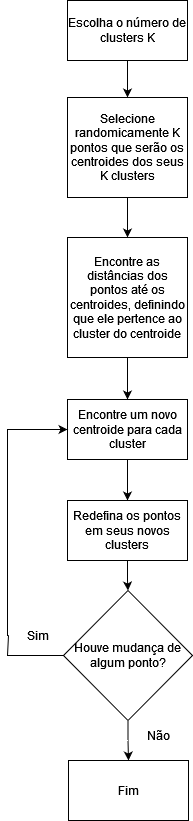

Exemplo visual:

https://www.youtube.com/watch?v=5I3Ei69I40s

#E como decidir qual o melhor número de clusters?

Vamos utilizar uma métrica para definir a soma dos quadrados em cada clustes (within cluster sum of squares = WCSS) para descobrir qual é a melhor quantidade de clusters possível.

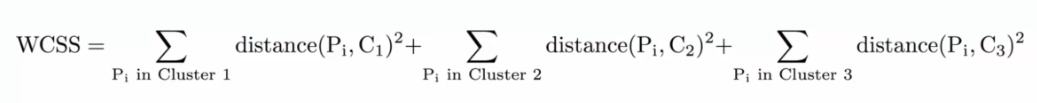

\begin{equation}
	WCSS = \sum_j \sum_i dist(P_i,C_j)^2
 \end{equation}

Como vocês acreditam que podemos definir a quantidade de clusters a partir da equação acima? Qual é o mínimo dela? Em qual condição?

#Random Inicialization Trap

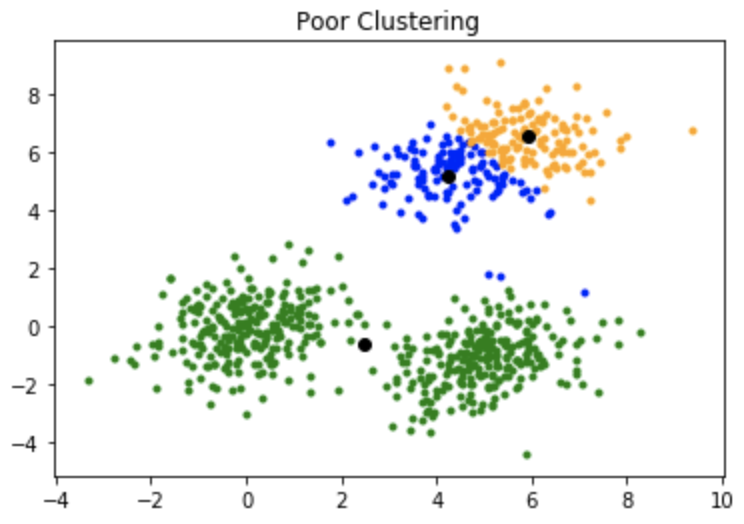

https://www.geeksforgeeks.org/ml-k-means-algorithm/

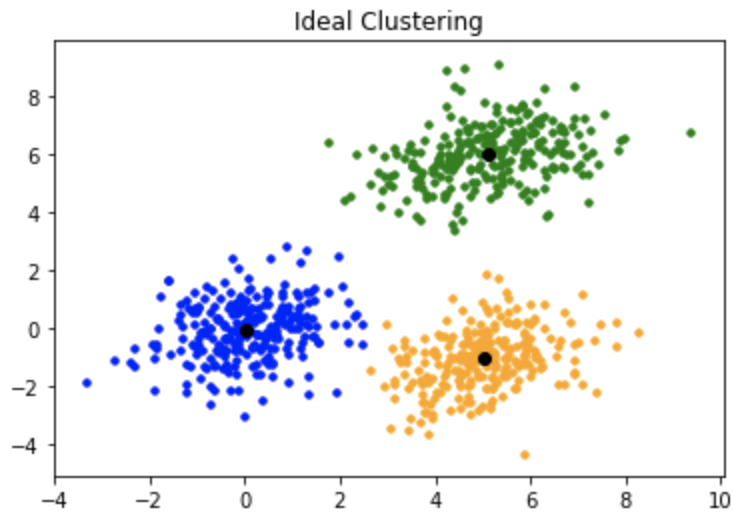

Para fugir dos mínimos locais que geram a condição acima designada como "poor clustering", precisamos definir uma forma melhor de chutar os centroides do que simplesmente escolher pontos randômicos.

Hoje o meio mais utilizado para encontrar este chute inicial dos centróides é o algoritmo de K-means ++:

- Selecione randômicamente o primeiro centroide;
- Calcule a distância de todos os pontos até o centroide mais próximo (se primeiro passo, até o único centroide);
- Selecione o próximo centroide como um dado do dataset, em que a probabilidade de escolhe-lo é proporcional a distância do centroide mais próximo previamente escolhido (ou seja, quanto mais longe, melhor);
- Repita os dois passos acima até obter todos os K centroides.

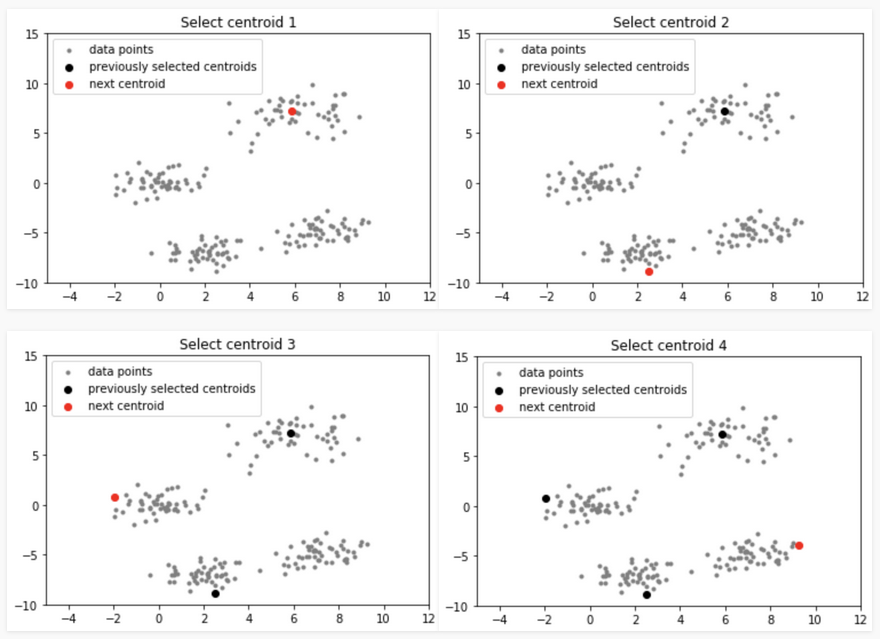

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html


#Aplicação em Python

In [1]:
#Imports básicos + visualização

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
#from matplotlib.colors import ListedColormap
import seaborn as sns
import plotly as py
import plotly.graph_objs as go

In [2]:
#Imports Sklearn

#from sklearn import tree

#Preprocessamento

#from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
#from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Regressão

#from sklearn.linear_model import LinearRegression
#from sklearn.tree import DecisionTreeRegressor
#from sklearn.ensemble import RandomForestRegressor
#from sklearn.svm import SVR
#from sklearn.neighbors import KNeighborsRegressor

#Classificação

#from sklearn.tree import DecisionTreeClassifier
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.neighbors import KNeighborsClassifier
#from sklearn.svm import SVC

#Avaliação e otimização

#from sklearn.metrics import r2_score
#from sklearn.metrics import mean_absolute_error
#from sklearn.metrics import accuracy_score
#from sklearn.metrics import confusion_matrix
#from sklearn.metrics import plot_confusion_matrix

#from sklearn.model_selection import cross_val_score
#from sklearn.model_selection import GridSearchCV

#Clustering

from sklearn.cluster import KMeans

In [3]:
path = 'https://raw.githubusercontent.com/OrlandoIFPR/ml2/refs/heads/main/Dataframes/'

In [5]:
dataset = pd.read_csv(path+ 'Mall_Customers.csv') #Kaggle https://www.kaggle.com/code/kushal1996/customer-segmentation-k-means-analysis/data

dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
X = dataset.iloc[:, [-2,-1]]
#X = X.dropna(axis=0)
X


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [14]:
#kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
kmeans = KMeans(n_clusters = 3, init = 'random', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

In [9]:
dataset_novo = X
X = X.values

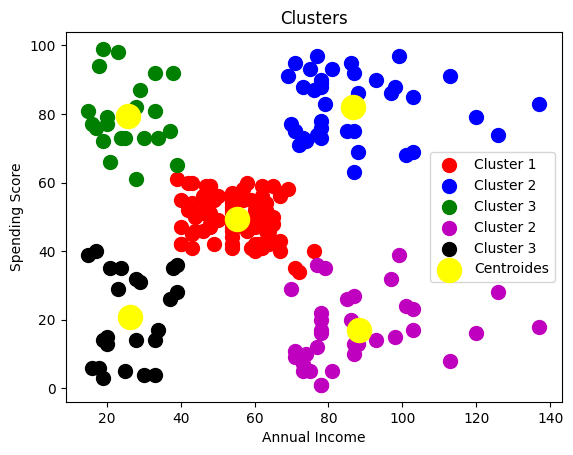

In [12]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'm', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'k', label = 'Cluster 3')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroides')
plt.title('Clusters')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

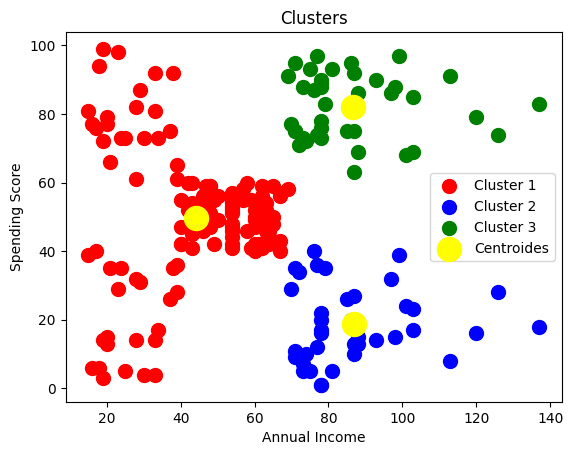

In [15]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
#plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'm', label = 'Cluster 2')
#plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'k', label = 'Cluster 3')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroides')
plt.title('Clusters')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
#kmeans = KMeans(n_clusters = 3, init = 'random', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

Text(0, 0.5, 'WCSS')

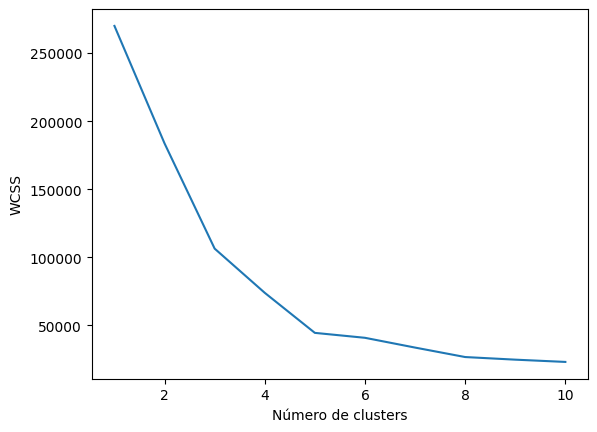

In [ ]:
wcss = []
for i in range(1, 11):
    #kmeans = KMeans(n_clusters = i, init = 'random', random_state = 42)
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')

In [ ]:
#kmeans = KMeans(n_clusters = 5, init = 'random', random_state = 42)
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

In [ ]:
y_kmeans

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
dataset_novo['cluster'] = y_kmeans

<ipython-input-15-d22f503d9b83>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_novo['cluster'] = y_kmeans


In [ ]:
dataset_novo.head()

,Annual Income (k$),Spending Score (1-100),cluster
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


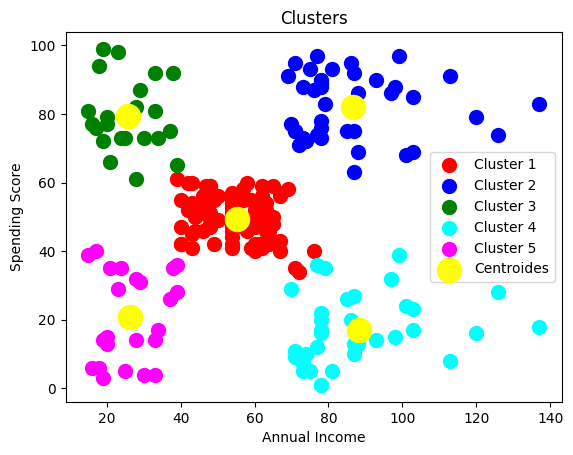

In [ ]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroides')
plt.title('Clusters')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [16]:
X2 = dataset.iloc[:, [-3,-2,-1]]
#X = X.dropna(axis=0)
X2


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


In [19]:
dataset_novo2 = X2
X2 = X2.values

Text(0, 0.5, 'WCSS')

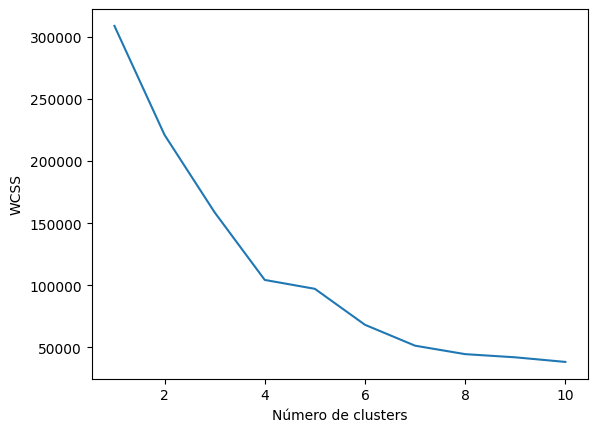

In [ ]:
wcss2 = []
for i in range(1, 11):
    kmeans2 = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans2.fit(X2)
    wcss2.append(kmeans2.inertia_)
plt.plot(range(1, 11), wcss2)
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')

In [17]:
kmeans2 = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans2 = kmeans2.fit_predict(X2)

In [20]:
dataset_novo2['cluster'] = y_kmeans2

<ipython-input-20-71e23d903bda>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_novo2['cluster'] = y_kmeans2


In [21]:
dataset_novo2.head()

,Age,Annual Income (k$),Spending Score (1-100),cluster
0,19,15,39,2
1,21,15,81,2
2,20,16,6,0
3,23,16,77,2
4,31,17,40,0


Text(0.5, 0, 'Spending Score (1-100)')

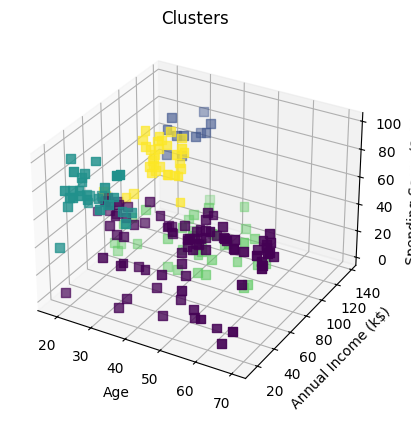

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = np.array(dataset_novo2['Age'])
y = np.array(dataset_novo2['Annual Income (k$)'])
z = np.array(dataset_novo2['Spending Score (1-100)'])

ax.scatter(x,y,z, marker="s", c=dataset_novo2["cluster"], s=40)

plt.title('Clusters')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')


In [ ]:
trace1 = go.Scatter3d(
    x= dataset_novo2['Age'],
    y= dataset_novo2['Spending Score (1-100)'],
    z= dataset_novo2['Annual Income (k$)'],
    mode='markers',
     marker=dict(
        color = dataset_novo2['cluster'],
        size= 10,
        line=dict(
            color= dataset_novo2['cluster'],
            width= 12
        ),
        opacity=0.8
     )
)
data = [trace1]
layout = go.Layout(
    title= 'Clusters',
    scene = dict(
            xaxis = dict(title  = 'Age'),
            yaxis = dict(title  = 'Spending Score'),
            zaxis = dict(title  = 'Annual Income')
        )
)
fig = go.Figure(data=data, layout=layout)
py.offline.iplot(fig)